# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [2]:
import pandas as pd
import numpy as np


### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [3]:
url = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv'
apple = pd.read_csv(url)
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


In [4]:
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 3. Assign it to a variable apple

In [5]:
apple.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

### Step 5. Transform the Date column as a datetime type

In [6]:
apple['Date'] = pd.to_datetime(apple['Date'])

### Step 6.  Set the date as the index

In [7]:
apple.set_index('Date', inplace=True)

### Step 7.  Is there any duplicate dates?

In [8]:
apple.index.duplicated().sum()

np.int64(0)

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [9]:
apple.sort_index(inplace=True)

### Step 9. Get the last business day of each month

In [15]:
apple.resample('BME').last()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,34.25,34.25,34.13,34.13,8937600,0.53
1981-01-30,28.50,28.50,28.25,28.25,11547200,0.44
1981-02-27,26.50,26.75,26.50,26.50,3690400,0.41
1981-03-31,24.75,24.75,24.50,24.50,3998400,0.38
1981-04-30,28.38,28.62,28.38,28.38,3152800,0.44
...,...,...,...,...,...,...
2014-03-31,539.23,540.81,535.93,536.74,42167300,76.25
2014-04-30,592.64,599.43,589.80,590.09,114160200,83.83
2014-05-30,637.98,644.17,628.90,633.00,141005200,90.43


### Step 10.  What is the difference in days between the first day and the oldest

In [11]:
(apple.index[-1] - apple.index[0]).days

12261

### Step 11.  How many months in the data we have?

In [16]:
len(apple.resample('ME'))

404

### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

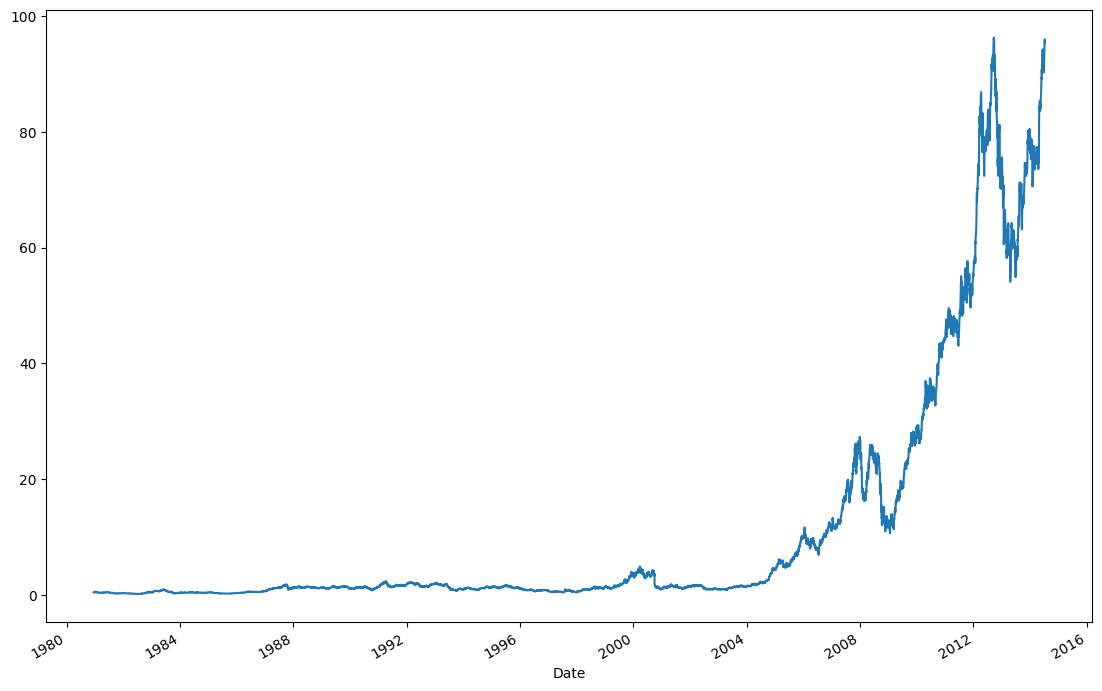

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(13.5, 9))
apple['Adj Close'].plot()
plt.show()

### BONUS: Create your own question and answer it.

In [17]:
# Question: What is the average closing price for each year?
year_avg = apple['Adj Close'].resample('YE').mean()
print("Average Adjusted Close Price by Year:")
print(year_avg)

Average Adjusted Close Price by Year:
Date
1980-12-31     0.473077
1981-12-31     0.378651
1982-12-31     0.298261
1983-12-31     0.584643
1984-12-31     0.417787
1985-12-31     0.314862
1986-12-31     0.505494
1987-12-31     1.215652
1988-12-31     1.305771
1989-12-31     1.322341
1990-12-31     1.205257
1991-12-31     1.702292
1992-12-31     1.792795
1993-12-31     1.354664
1994-12-31     1.142738
1995-12-31     1.375556
1996-12-31     0.850709
1997-12-31     0.613123
1998-12-31     1.043413
1999-12-31     1.972063
2000-12-31     3.120873
2001-12-31     1.380484
2002-12-31     1.306825
2003-12-31     1.265992
2004-12-31     2.425635
2005-12-31     6.373651
2006-12-31     9.668964
2007-12-31    17.515219
2008-12-31    19.386324
2009-12-31    20.047063
2010-12-31    35.479802
2011-12-31    49.703135
2012-12-31    78.847600
2013-12-31    65.994563
2014-12-31    80.837674
Freq: YE-DEC, Name: Adj Close, dtype: float64
